# The uncertainty principle -- from ultrashort pulses to energy and time
### a short pulse MUST be broadband: $\Delta t\,\Delta\omega\ge\tfrac12$, so $\Delta E\,\Delta t\ge\tfrac{\hbar}{2}$

You cannot make a pulse both short in time and narrow in spectrum -- their rms
widths are locked together. A **Gaussian** saturates the bound (the transform-limited
pulse); a chirp or a hard edge only makes it worse. Multiply by $\hbar$ and the same
inequality becomes **energy-time uncertainty**: a femtosecond pulse spans a broad
band of photon energies. That broadband content is *why dispersion matters* in this
repo -- a wide spectrum spreads in time as it propagates. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import uncertainty as un
sp.init_printing()
print("ready; hbar =", un.HBAR, "J s")

ready; hbar = 1.054571817e-34 J s


## 1. Short pulse -> broad spectrum (the time-bandwidth product)

Two Gaussian pulses: a long one and one half as short. The short pulse has a
spectrum **twice as wide** -- and both sit exactly on the floor
$\Delta t\,\Delta\omega=\tfrac12$.

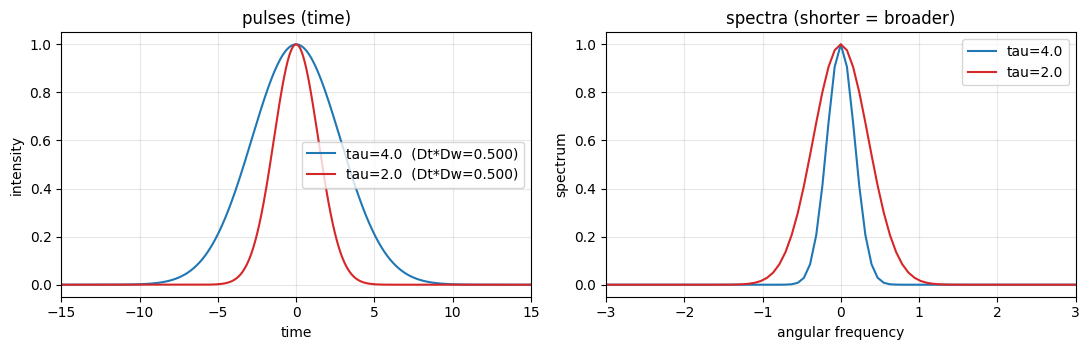

shorter pulse -> wider spectrum; product pinned at 0.5 (transform-limited)


In [2]:
t = np.linspace(-40, 40, 8192)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for tau, c in [(4.0, "C0"), (2.0, "C3")]:
    f = un.gaussian_pulse(t, tau)
    w, F = un.spectrum(t, f)
    tbp = un.time_bandwidth_product(t, f)
    ax[0].plot(t, np.abs(f)**2, c, label=f"tau={tau}  (Dt*Dw={tbp:.3f})")
    ax[1].plot(w, np.abs(F)**2/np.abs(F).max()**2, c, label=f"tau={tau}")
ax[0].set(xlim=(-15,15), xlabel="time", ylabel="intensity", title="pulses (time)")
ax[1].set(xlim=(-3,3), xlabel="angular frequency", ylabel="spectrum", title="spectra (shorter = broader)")
for a in ax: a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("shorter pulse -> wider spectrum; product pinned at 0.5 (transform-limited)")

## 2. SymPy: the harmonic-oscillator modes -- $\Delta x\,\Delta p=\tfrac{2n+1}{2}\hbar$

The same uncertainty product, exactly, for the quantum harmonic oscillator's
energy eigenstates $\psi_n$ (Hermite-Gaussians). Looping over the first **five**
integer modes $n=0,\dots,4$ and integrating symbolically (units $\hbar=m\omega=1$):
the **ground state $n=0$ is a Gaussian and gives $\tfrac12$** -- the *same* minimum
as the transform-limited pulse -- and each higher mode adds one full quantum.

In [3]:
x = sp.Symbol("x", real=True)
def psi(n):
    return sp.hermite(n, x) * sp.exp(-x**2/2) / sp.sqrt(2**n * sp.factorial(n) * sp.sqrt(sp.pi))
products = []
for n in range(5):                                   # five integer modes
    p = psi(n)
    x2 = sp.integrate(x**2 * p**2, (x, -sp.oo, sp.oo))         # <x^2>
    p2 = sp.integrate(sp.diff(p, x)**2, (x, -sp.oo, sp.oo))    # <p^2> = int |psi'|^2
    dxdp = sp.sqrt(x2) * sp.sqrt(p2)
    products.append(dxdp)
    print(f"n={n}:")
    display(sp.Eq(sp.Symbol("Delta_x*Delta_p"), dxdp))
print("ground state (n=0, a Gaussian) = 1/2 = the uncertainty floor = the TL pulse")

n=0:


n=1:


n=2:

n=3:


n=4:


ground state (n=0, a Gaussian) = 1/2 = the uncertainty floor = the TL pulse


## 3. Energy-time: a femtosecond pulse spans electron-volts

Since $\Delta E=\hbar\,\Delta\omega$, the bound becomes
$\Delta E\,\Delta t\ge\hbar/2$: the shorter the pulse, the wider its spread of
**photon energies**. Put in real units -- a few-femtosecond pulse already spans tens
to hundreds of meV.

In [4]:
eV = 1.602176634e-19
print("transform-limited pulse:  Delta_E = hbar/(2 Delta_t)")
for dt_fs in (50, 10, 4):
    dt = dt_fs*1e-15
    dE = un.HBAR/(2*dt)
    print(f"  Delta_t = {dt_fs:3d} fs  ->  Delta_E = {dE:.3e} J = {dE/eV*1e3:.1f} meV")
print("=> the broadband photon-energy content of an ultrashort pulse is unavoidable.")

transform-limited pulse:  Delta_E = hbar/(2 Delta_t)
  Delta_t =  50 fs  ->  Delta_E = 1.055e-21 J = 6.6 meV
  Delta_t =  10 fs  ->  Delta_E = 5.273e-21 J = 32.9 meV
  Delta_t =   4 fs  ->  Delta_E = 1.318e-20 J = 82.3 meV
=> the broadband photon-energy content of an ultrashort pulse is unavoidable.


## 4. Chirp -- same duration, wider band (the dispersion connection)

A linear chirp (a quadratic spectral phase) leaves the **intensity** envelope -- and
so $\Delta t$ -- untouched, but spreads $\Delta\omega$, pushing the product above
$\tfrac12$. That is exactly what **dispersion** does to a pulse: it chirps it. So the
chirped pulses the receiver works with are no longer transform-limited.

  chirp=0.0:  Dt=1.414 (fixed)  Dw=0.354  Dt*Dw=0.500
  chirp=0.2:  Dt=1.414 (fixed)  Dw=0.667  Dt*Dw=0.943
  chirp=0.5:  Dt=1.414 (fixed)  Dw=1.458  Dt*Dw=2.062


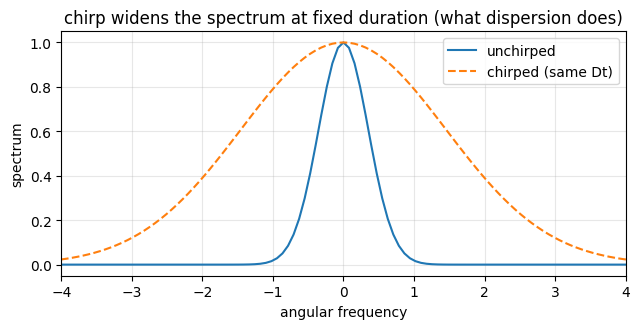

In [5]:
for chirp in (0.0, 0.2, 0.5):
    fc = un.gaussian_pulse(t, 2.0, chirp=chirp)
    w, F = un.spectrum(t, fc)
    Dt = un.rms_width(t, np.abs(fc)**2)
    Dw = un.rms_width(w, np.abs(F)**2)
    print(f"  chirp={chirp}:  Dt={Dt:.3f} (fixed)  Dw={Dw:.3f}  Dt*Dw={Dt*Dw:.3f}")

w0, F0 = un.spectrum(t, un.gaussian_pulse(t, 2.0, chirp=0.0))
w5, F5 = un.spectrum(t, un.gaussian_pulse(t, 2.0, chirp=0.5))
plt.figure(figsize=(6.5,3.4))
plt.plot(w0, np.abs(F0)**2/np.abs(F0).max()**2, label="unchirped")
plt.plot(w5, np.abs(F5)**2/np.abs(F5).max()**2, "--", label="chirped (same Dt)")
plt.xlim(-4,4); plt.xlabel("angular frequency"); plt.ylabel("spectrum"); plt.legend()
plt.title("chirp widens the spectrum at fixed duration (what dispersion does)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Takeaway

1. $\Delta t\,\Delta\omega\ge\tfrac12$: a short pulse is necessarily broadband; the
   Gaussian (transform-limited) sits on the floor.
2. The **quantum** version is identical -- the harmonic-oscillator ground state (a
   Gaussian) gives $\tfrac{\hbar}{2}$, higher modes $\tfrac{(2n+1)\hbar}{2}$.
3. **Energy-time:** $\Delta E\,\Delta t\ge\hbar/2$ -- femtosecond pulses span
   meV-to-eV photon energies.
4. **Chirp = dispersion:** same duration, wider band, product above the floor -- the
   reason this whole repo cares about $H(f)=e^{i\pi Df^2}$.

Next door in modern physics: **Compton scattering** ($\Delta\lambda=\tfrac{h}{mc}(1-\cos\theta)$)
and **bremsstrahlung** are the photon-energy side of the same light-matter story.
Civilian education.